In [13]:
from graphviz import Source
from IPython.display import display, Image

In [14]:
show_graph = lambda graph: display(Image(Source(graph).pipe(format='png')))

In [15]:
method_selection = """
digraph MethodSelection {
    rankdir=LR;
    node [fontname="Arial", style="rounded,filled", fontsize=8];
    edge [fontname="Arial", fontsize=10];
    nodesep=0.6;
    ranksep=0.6;

    Start [label="Какова цель анализа?", shape=ellipse, fillcolor="#81D4FA"];

    node [shape=box, fillcolor="#FFF9C4"]
    CompareMetricToValue [label="Сравнение метрики\nс заданным значением\n(одна выборка)"];
    CheckDistribution [label="Проверка согласованности\nс теоретическим распределением"];
    GroupComparison [label="Сравнение групп"];

    VarianceKnown [label="Дисперсия известна?", fillcolor="#E0F7FA"];

    node [shape=box, fillcolor="#C8E6C9"]
    ZTest1 [label="z-test"];
    TTest1 [label="t-test"];
    ChiSquareTest [label="χ²\n(goodness-of-fit)"];

    GroupTests [label="Тесты для групп", shape=ellipse, fillcolor="#81D4FA"];

    Start -> CompareMetricToValue;
    Start -> CheckDistribution;
    Start -> GroupComparison;

    CompareMetricToValue -> VarianceKnown;
    VarianceKnown -> ZTest1 [xlabel="Да"];
    VarianceKnown -> TTest1 [xlabel="Нет"];

    // Ветка 2: Проверка согласованности
    CheckDistribution -> ChiSquareTest;

    // Ветка 3: Сравнение групп
    GroupComparison -> GroupTests;
}
"""

In [16]:
multigroup_tests = """
digraph MethodSelectionForMultipleGroups {
    rankdir=LR;
    node [fontname="Arial", style="rounded,filled", fontsize=8];
    edge [fontname="Arial", fontsize=10];
    nodesep=0.6;
    ranksep=0.6;

    Start [label="Выбор\nстатистического метода", shape=ellipse, fillcolor="#81D4FA"];

    node[shape=box, fillcolor="#E0F7FA"]
    TwoGroups [label="2 группы"];
    ThreePlusGroups [label="3+ группы"];
    VarTwo [label="Дисперсии известны?"];

    node[shape=box, fillcolor="#C8E6C9"]
    DepTwoTest [label="paired t-test"];
    ZTest [label="z-test\n(для двух независимых групп\nс известными дисперсиями)"];
    TTestEqualF [label="t-test\n(для двух независимых групп\nс равными дисперсиями)"];
    TTestUnequalF [label="Welch t-test\n(для двух независимых групп\nс неравными дисперсиями)"];
    ANOVAEqual [label="ANOVA (one-way)\n(сравнение средних в 3+ группах\nс гомогенными дисперсиями)"];
    WelchANOVA [label="Welch ANOVA\n(альтернатива ANOVA\nпри негомогенных дисперсиях)"];

    node[fillcolor="#FFCCBC"]
    NonparamTwo [label="Непараметрические метод:\n- Mann-Whitney U\n(независимые)\n- Wilcoxon signed-rank\n(зависимые)"];
    NonparamThree [label="Непараметрический метод:\n- Kruskal-Wallis"];
    OtherMultiGroup [label="Другие методы:\n- Repeated Measures ANOVA\n- Friedman test"];

    node[fillcolor="#FFF9C4"]
    NormTwo [label="Shapiro-Wilk test\n(распределение нормально?)"];
    NormThree [label="Shapiro-Wilk test\n(распределение нормально?)"];
    FVarTest [label="F-test\n(дисперсии равны?)"];
    LeveneTest [label="Levene test\n(дисперсии гомогенны?)"];

    node[fillcolor="#E1BEE7"]
    ANOVA_Sig [label="Post-hoc тест:\n- Tukey HSD"];
    GamesHowell [label="Post-hoc тест:\nGames-Howell"];

    Start -> TwoGroups;
    Start -> ThreePlusGroups;

    TwoGroups -> DepTwoTest [label="Зависимые"];
    TwoGroups -> NormTwo [label="Независимые"];

    NormTwo -> VarTwo [label="нормально\n(p > 0.05)"];
    NormTwo -> NonparamTwo [label="не нормально\n(p ≤ 0.05)"];

    VarTwo -> ZTest [label="да"];
    VarTwo -> FVarTest [label="нет"];

    FVarTest -> TTestEqualF [label="равны\n(p > 0.05)"];
    FVarTest -> TTestUnequalF [label="неравны\n(p ≤ 0.05)"];

    ThreePlusGroups -> OtherMultiGroup [label="Зависимые"];
    ThreePlusGroups -> NormThree [label="Независимые"];

    NormThree -> LeveneTest [label="нормально\n(p > 0.05)"];
    NormThree -> NonparamThree [label="не нормально\n(p ≤ 0.05)"];

    LeveneTest -> ANOVAEqual [label="гомогенны\n(p > 0.05)"];
    ANOVAEqual -> ANOVA_Sig [label="Если результат\nстатистически значимый"];

    LeveneTest -> WelchANOVA [label="негомогенны\n(p ≤ 0.05)"];
    WelchANOVA -> GamesHowell [label="Если результат\nстатистически значимый"];
}
"""

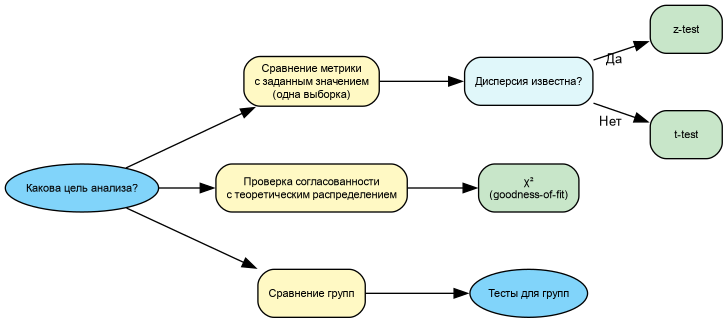

In [17]:
show_graph(method_selection)

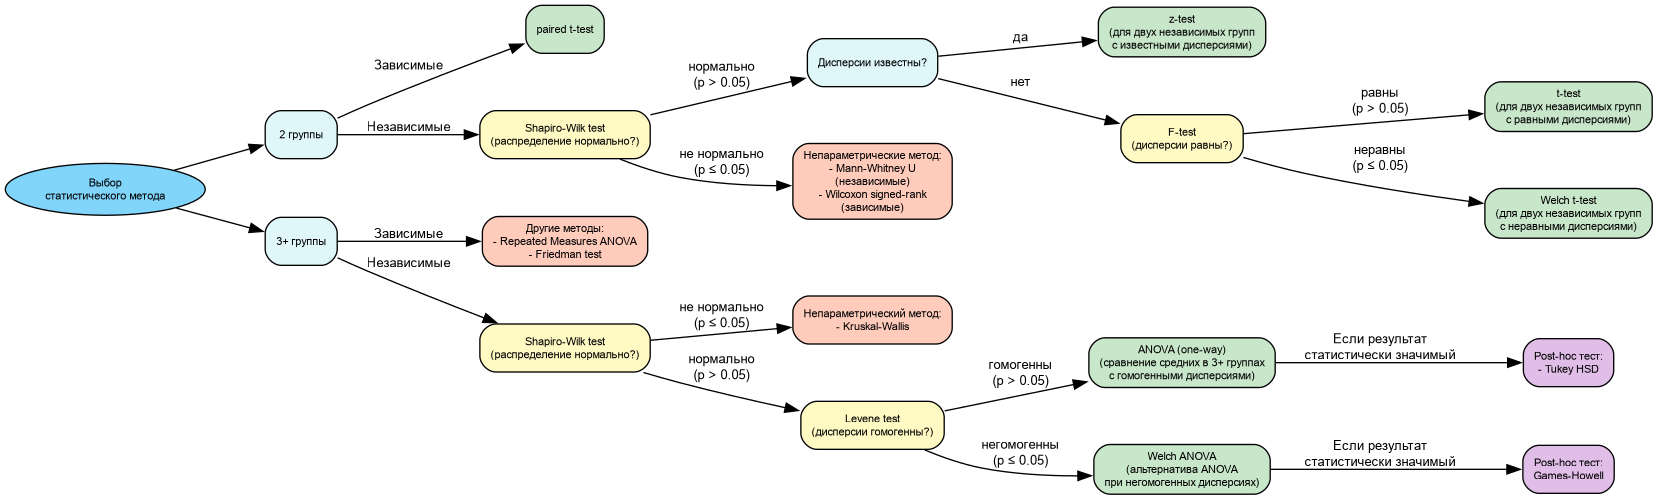

In [18]:
show_graph(multigroup_tests)